# 🦴 Pipeline U-Net para Detecção de Fraturas Ósseas

## Segmentação Semântica Binária com Deep Learning (PyTorch)

**Dataset:** Bone Fractures Detection (Roboflow - YOLOv8 format)

**Objetivo:** Localizar e segmentar regiões de fratura em imagens de raio-X ósseas.

**Arquitetura:** U-Net com encoder ResNet34 pré-treinado (ImageNet)

**Abordagem:** Os rótulos YOLO (bounding boxes) são convertidos em máscaras de segmentação binárias:
- **Positivo (1):** Regiões dentro de bounding boxes de fraturas
- **Negativo (0):** Fundo / ossos saudáveis

**Classes do Dataset (10):**
| Índice | Classe | Tipo |
|--------|--------|------|
| 0 | Comminuted | Fratura |
| 1 | Greenstick | Fratura |
| 2 | Healthy | Saudável |
| 3 | Linear | Fratura |
| 4 | Oblique Displaced | Fratura |
| 5 | Oblique | Fratura |
| 6 | Segmental | Fratura |
| 7 | Spiral | Fratura |
| 8 | Transverse Displaced | Fratura |
| 9 | Transverse | Fratura |

**Pipeline:**
1. Conversão de labels YOLO → máscaras binárias de segmentação
2. Pré-processamento: CLAHE + Gaussian Blur + Normalização
3. Data Augmentation agressiva (Albumentations)
4. U-Net com encoder pré-treinado (transfer learning)
5. Loss: BCE + Dice Loss combinada
6. Métricas: mIoU, Dice Score, Precision, Recall

## 1. Importações e Instalação de Dependências

Importamos todas as bibliotecas necessárias:
- **PyTorch**: Framework de Deep Learning
- **segmentation_models_pytorch (SMP)**: Arquiteturas de segmentação prontas
- **Albumentations**: Augmentação de dados eficiente
- **OpenCV**: CLAHE e Gaussian Blur

In [1]:
# Instalação (executar apenas uma vez, descomente se necessário):
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install segmentation-models-pytorch albumentations opencv-python-headless tqdm matplotlib

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

# Reproducibilidade
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

print(f'PyTorch version: {torch.__version__}')
print(f'SMP version: {smp.__version__}')
print(f'Albumentations version: {A.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    mem_gb = torch.cuda.get_device_properties(0).total_mem / 1e9
    print(f'GPU Memory: {mem_gb:.1f} GB')

PyTorch version: 2.5.1+cu121
SMP version: 0.5.0
Albumentations version: 2.0.8
CUDA available: False


## 2. Configuração

Todas as configurações centralizadas em uma classe:
- **Dataset**: Bone Fractures Detection (Roboflow, YOLOv8 format)
- **Classe 2 (Healthy)** é excluída das classes positivas
- **9 classes de fratura** mapeadas como positivo na máscara binária
- `IMG_SIZE = 512`: Redimensionado para otimizar memória
- `BATCH_SIZE = 4`: Otimizado para GPUs com 4-8 GB de VRAM

In [3]:
class Config:
    # === Caminhos do Dataset Bone Fractures Detection ===
    BASE_DIR = os.path.dirname(os.path.abspath('__file__'))  # diretório do notebook
    DATA_DIR = os.path.join(BASE_DIR, "Bone Fractures Detection")
    TRAIN_DIR = os.path.join(DATA_DIR, "train")
    VALID_DIR = os.path.join(DATA_DIR, "valid")
    TEST_DIR = os.path.join(DATA_DIR, "test")
    
    # Subdiretórios do dataset YOLO
    IMAGES_SUBDIR = "images"
    LABELS_SUBDIR = "labels"
    
    # Diretórios de saída
    CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
    RESULTS_DIR = os.path.join(BASE_DIR, "results")
    
    # === Imagem ===
    IMG_SIZE = 512       # Resolução para treino (imagens originais são 640x640)
    IN_CHANNELS = 3      # RGB para compatibilidade com ImageNet
    NUM_CLASSES = 1       # Segmentação binária (fratura vs fundo)
    
    # === Classes do Dataset ===
    CLASS_NAMES = [
        'Comminuted',           # 0 - Fratura cominutiva
        'Greenstick',           # 1 - Fratura em galho verde
        'Healthy',              # 2 - Saudável (NÃO é fratura)
        'Linear',               # 3 - Fratura linear
        'Oblique Displaced',    # 4 - Fratura oblíqua deslocada
        'Oblique',              # 5 - Fratura oblíqua
        'Segmental',            # 6 - Fratura segmentar
        'Spiral',               # 7 - Fratura espiral
        'Transverse Displaced', # 8 - Fratura transversal deslocada
        'Transverse',           # 9 - Fratura transversal
    ]
    
    # Classes positivas (todas as fraturas, excluindo Healthy=2)
    FRACTURE_CLASSES = [0, 1, 3, 4, 5, 6, 7, 8, 9]
    HEALTHY_CLASS = 2
    
    # === Treinamento ===
    EPOCHS = 100
    BATCH_SIZE = 4
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    
    # === Early Stopping ===
    PATIENCE = 15
    
    # === Modelo ===
    ENCODER = "resnet34"
    ENCODER_WEIGHTS = "imagenet"
    
    # === Device ===
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = Config()

# Criar diretórios de saída
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)

print(f'Device: {cfg.DEVICE}')
print(f'Image size: {cfg.IMG_SIZE}x{cfg.IMG_SIZE}')
print(f'Fracture classes: {cfg.FRACTURE_CLASSES}')
print(f'Fracture class names: {[cfg.CLASS_NAMES[i] for i in cfg.FRACTURE_CLASSES]}')
print(f'Healthy class: {cfg.HEALTHY_CLASS} ({cfg.CLASS_NAMES[cfg.HEALTHY_CLASS]})')
print(f'Batch size: {cfg.BATCH_SIZE}')
print(f'Max epochs: {cfg.EPOCHS}')
print(f'Early stopping patience: {cfg.PATIENCE}')
print(f'\nDataset directories:')
print(f'  Train: {cfg.TRAIN_DIR} (exists: {os.path.exists(cfg.TRAIN_DIR)})')
print(f'  Valid: {cfg.VALID_DIR} (exists: {os.path.exists(cfg.VALID_DIR)})')
print(f'  Test:  {cfg.TEST_DIR} (exists: {os.path.exists(cfg.TEST_DIR)})')

Device: cpu
Image size: 512x512
Fracture classes: [0, 1, 3, 4, 5, 6, 7, 8, 9]
Fracture class names: ['Comminuted', 'Greenstick', 'Linear', 'Oblique Displaced', 'Oblique', 'Segmental', 'Spiral', 'Transverse Displaced', 'Transverse']
Healthy class: 2 (Healthy)
Batch size: 4
Max epochs: 100
Early stopping patience: 15

Dataset directories:
  Train: c:\Users\leona\OneDrive\Documentos\Unet_bones\Bone Fractures Detection\train (exists: True)
  Valid: c:\Users\leona\OneDrive\Documentos\Unet_bones\Bone Fractures Detection\valid (exists: True)
  Test:  c:\Users\leona\OneDrive\Documentos\Unet_bones\Bone Fractures Detection\test (exists: True)


## 3. Pré-processamento de Imagem

### CLAHE (Contrast Limited Adaptive Histogram Equalization)
- Melhora o contraste local em raio-X
- Realça bordas de fraturas que podem ser sutis
- Aplicado no espaço LAB (canal L = luminância)

### Gaussian Blur
- Reduz ruído de alta frequência em radiografias
- Kernel 3x3 preserva detalhes de fraturas finas

In [4]:
def apply_clahe(image, clip_limit=3.0, tile_grid_size=(8, 8)):
    """Aplica CLAHE para melhorar contraste em raio-X."""
    if len(image.shape) == 3:
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    else:
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        image = clahe.apply(image)
    return image


def apply_gaussian_blur(image, kernel_size=3):
    """Aplica Gaussian Blur para redução de ruído (kernel 3x3)."""
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)


def preprocess_image(image):
    """
    Pipeline de pré-processamento completo:
    1. CLAHE -> realça contraste de fraturas
    2. Gaussian Blur -> reduz ruído
    """
    image = apply_clahe(image, clip_limit=3.0)
    image = apply_gaussian_blur(image, kernel_size=3)
    return image

print("Funções de pré-processamento definidas.")

Funções de pré-processamento definidas.


## 4. Conversão de Labels YOLO → Máscaras de Segmentação

O dataset Bone Fractures Detection usa o formato **YOLO** para anotações:
- Cada linha: `class_id x_center y_center width height` (valores normalizados 0-1)

Convertemos cada bounding box de fratura em uma **região preenchida** na máscara binária.
- Classes de fratura (0,1,3-9) → preenchidas com 1
- Classe Healthy (2) → ignorada (não gera máscara)
- Fundo → 0

In [5]:
def parse_yolo_label(label_path):
    """
    Lê um arquivo de label YOLO e retorna lista de (class_id, x_center, y_center, w, h).
    Valores são normalizados (0-1).
    """
    annotations = []
    if not os.path.exists(label_path):
        return annotations
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                w = float(parts[3])
                h = float(parts[4])
                annotations.append((class_id, x_center, y_center, w, h))
    return annotations


def yolo_to_binary_mask(label_path, img_h, img_w, fracture_classes):
    """
    Converte labels YOLO em máscara de segmentação binária.
    
    Args:
        label_path: Caminho do arquivo .txt com labels YOLO
        img_h: Altura da imagem em pixels
        img_w: Largura da imagem em pixels
        fracture_classes: Lista de IDs de classes que representam fraturas
    
    Returns:
        mask: Array numpy float32, shape (H, W), valores 0 ou 1
    """
    mask = np.zeros((img_h, img_w), dtype=np.float32)
    
    annotations = parse_yolo_label(label_path)
    
    for class_id, xc, yc, w, h in annotations:
        # Ignorar classe Healthy
        if class_id not in fracture_classes:
            continue
        
        # Converter coordenadas normalizadas para pixels
        x1 = int((xc - w / 2) * img_w)
        y1 = int((yc - h / 2) * img_h)
        x2 = int((xc + w / 2) * img_w)
        y2 = int((yc + h / 2) * img_h)
        
        # Clamp para limites da imagem
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img_w, x2)
        y2 = min(img_h, y2)
        
        # Preencher região do bounding box na máscara
        mask[y1:y2, x1:x2] = 1.0
    
    return mask

print("Funções de conversão YOLO → Máscara definidas.")

Funções de conversão YOLO → Máscara definidas.


## 5. Descoberta de Pares Imagem/Label

O dataset possui estrutura YOLO padrão:
- Imagens: `{split}/images/nome.jpg`
- Labels: `{split}/labels/nome.txt`

Match é feito pelo nome base do arquivo (sem extensão).

In [6]:
def discover_pairs(split_dir, images_subdir='images', labels_subdir='labels'):
    """
    Descobre pares imagem/label em um diretório com estrutura YOLO.
    Estrutura: split_dir/images/*.jpg e split_dir/labels/*.txt
    """
    images_dir = os.path.join(split_dir, images_subdir)
    labels_dir = os.path.join(split_dir, labels_subdir)
    
    if not os.path.exists(images_dir):
        print(f'  ERRO: Diretório de imagens não encontrado: {images_dir}')
        return []
    
    if not os.path.exists(labels_dir):
        print(f'  ERRO: Diretório de labels não encontrado: {labels_dir}')
        return []
    
    # Encontrar arquivos de imagem
    image_files = sorted([
        f for f in os.listdir(images_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    
    label_files = set(os.listdir(labels_dir))
    
    pairs = []
    missing = []
    
    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        label_file = base_name + '.txt'
        
        img_path = os.path.join(images_dir, img_file)
        label_path = os.path.join(labels_dir, label_file)
        
        if label_file in label_files:
            pairs.append((img_path, label_path))
        else:
            # Imagens sem label podem ser completamente saudáveis
            # Incluímos com label_path=None (máscara será toda zero)
            pairs.append((img_path, None))
            missing.append(img_file)
    
    if missing:
        print(f'  AVISO: {len(missing)} imagens sem label (tratadas como saudáveis)')
        for m in missing[:5]:
            print(f'    - {m}')
    
    return pairs


# Descobrir pares em cada split
train_pairs = discover_pairs(cfg.TRAIN_DIR)
valid_pairs = discover_pairs(cfg.VALID_DIR)
test_pairs = discover_pairs(cfg.TEST_DIR)

print(f'\nDataset Summary:')
print(f'  Train: {len(train_pairs)} pares')
print(f'  Valid: {len(valid_pairs)} pares')
print(f'  Test:  {len(test_pairs)} pares')
print(f'  Total: {len(train_pairs) + len(valid_pairs) + len(test_pairs)} pares')


Dataset Summary:
  Train: 1347 pares
  Valid: 128 pares
  Test:  64 pares
  Total: 1539 pares


## 6. Dataset Customizado (PyTorch)

O `BoneFractureDataset` estende `torch.utils.data.Dataset`:
1. **Carregamento**: Lê imagens JPG e labels YOLO (.txt)
2. **Conversão**: Labels YOLO → máscara binária de segmentação
3. **Pré-processamento**: CLAHE + Gaussian Blur
4. **Augmentação**: Pipeline Albumentations
5. **Saída**: Tensores `[C, H, W]` (imagem) e `[1, H, W]` (máscara)

In [7]:
class BoneFractureDataset(Dataset):
    """Dataset para segmentação de fraturas ósseas a partir de labels YOLO."""
    
    def __init__(self, pairs, fracture_classes, img_size=512,
                 transform=None, apply_preprocess=True):
        self.pairs = pairs
        self.fracture_classes = fracture_classes
        self.img_size = img_size
        self.transform = transform
        self.apply_preprocess = apply_preprocess
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        img_path, label_path = self.pairs[idx]
        
        # Carregar imagem (BGR -> RGB)
        image = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f'Imagem não encontrada: {img_path}')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        img_h, img_w = image.shape[:2]
        
        # Gerar máscara binária a partir dos labels YOLO
        if label_path is not None and os.path.exists(label_path):
            binary_mask = yolo_to_binary_mask(
                label_path, img_h, img_w, self.fracture_classes
            )
        else:
            # Sem label = imagem saudável = máscara toda zero
            binary_mask = np.zeros((img_h, img_w), dtype=np.float32)
        
        # Pré-processamento (CLAHE + Gaussian Blur)
        if self.apply_preprocess:
            image = preprocess_image(image)
        
        # Augmentação e transformação
        if self.transform:
            augmented = self.transform(image=image, mask=binary_mask)
            image = augmented['image']       # Tensor [C, H, W]
            binary_mask = augmented['mask']   # Tensor [H, W]
        
        # Garantir dimensão do canal na máscara
        if isinstance(binary_mask, np.ndarray):
            binary_mask = torch.from_numpy(binary_mask).float()
        
        if binary_mask.ndim == 2:
            binary_mask = binary_mask.unsqueeze(0)  # [H, W] -> [1, H, W]
        
        return image, binary_mask

print("BoneFractureDataset definido.")

BoneFractureDataset definido.


## 7. Data Augmentation (Albumentations)

Augmentação agressiva para maximizar a generalização:

| Transformação | Propósito | Prob |
|---|---|---|
| `HorizontalFlip` | Simetria lateral | 50% |
| `VerticalFlip` | Variação posicional | 30% |
| `Rotate(±15°)` | Variação de posicionamento | 50% |
| `ShiftScaleRotate` | Translação e escala | 30% |
| `ElasticTransform` | Deformações anatômicas | 20% |
| `RandomBrightnessContrast` | Variação de exposição | 30% |
| `CLAHE` | Contraste adicional | 30% |
| `GaussNoise` | Ruído do detector | 30% |

In [8]:
def get_train_transform(img_size):
    """Pipeline de augmentação para treino (agressivo)."""
    return A.Compose([
        A.Resize(img_size, img_size, interpolation=cv2.INTER_LINEAR),
        
        # Augmentações geométricas
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
        A.ShiftScaleRotate(
            shift_limit=0.1, scale_limit=0.15, rotate_limit=0,
            p=0.3, border_mode=cv2.BORDER_CONSTANT
        ),
        A.ElasticTransform(alpha=50, sigma=50 * 0.05, p=0.2),
        
        # Augmentações fotométricas
        A.RandomBrightnessContrast(
            brightness_limit=0.2, contrast_limit=0.2, p=0.3
        ),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.3),
        A.GaussNoise(p=0.3),
        
        # Normalização ImageNet
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])


def get_valid_transform(img_size):
    """Pipeline para validação/teste (apenas resize + normalize)."""
    return A.Compose([
        A.Resize(img_size, img_size, interpolation=cv2.INTER_LINEAR),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

print('Pipelines de augmentação definidos.')
print(f'  Train: {len(get_train_transform(cfg.IMG_SIZE).transforms)} transformações')
print(f'  Valid: {len(get_valid_transform(cfg.IMG_SIZE).transforms)} transformações')

Pipelines de augmentação definidos.
  Train: 11 transformações
  Valid: 3 transformações


## 8. Criação dos DataLoaders

DataLoaders gerenciam batching, shuffling, pin memory e carregamento paralelo.

In [9]:
# Criar datasets
train_dataset = BoneFractureDataset(
    pairs=train_pairs,
    fracture_classes=cfg.FRACTURE_CLASSES,
    img_size=cfg.IMG_SIZE,
    transform=get_train_transform(cfg.IMG_SIZE)
)

valid_dataset = BoneFractureDataset(
    pairs=valid_pairs,
    fracture_classes=cfg.FRACTURE_CLASSES,
    img_size=cfg.IMG_SIZE,
    transform=get_valid_transform(cfg.IMG_SIZE)
)

test_dataset = BoneFractureDataset(
    pairs=test_pairs,
    fracture_classes=cfg.FRACTURE_CLASSES,
    img_size=cfg.IMG_SIZE,
    transform=get_valid_transform(cfg.IMG_SIZE)
)

# Criar DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=cfg.BATCH_SIZE,
    shuffle=True, num_workers=0, pin_memory=True, drop_last=True
)

valid_loader = DataLoader(
    valid_dataset, batch_size=cfg.BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=True
)

test_loader = DataLoader(
    test_dataset, batch_size=1,
    shuffle=False, num_workers=0, pin_memory=True
)

# Verificar shapes
sample_img, sample_mask = next(iter(train_loader))
print(f'Shapes:')
print(f'  Image batch: {sample_img.shape}  (B, C, H, W)')
print(f'  Mask batch:  {sample_mask.shape}  (B, 1, H, W)')
print(f'  Image dtype: {sample_img.dtype}')
print(f'  Mask dtype:  {sample_mask.dtype}')
print(f'  Mask unique: {torch.unique(sample_mask).tolist()}')
print(f'\nBatches:')
print(f'  Train: {len(train_loader)} batches x {cfg.BATCH_SIZE}')
print(f'  Valid: {len(valid_loader)} batches')
print(f'  Test:  {len(test_loader)} batches')

Shapes:
  Image batch: torch.Size([4, 3, 512, 512])  (B, C, H, W)
  Mask batch:  torch.Size([4, 1, 512, 512])  (B, 1, H, W)
  Image dtype: torch.float32
  Mask dtype:  torch.float32
  Mask unique: [0.0, 1.0]

Batches:
  Train: 336 batches x 4
  Valid: 32 batches
  Test:  64 batches


## 9. Cálculo do Peso das Classes (Balanceamento)

Fraturas geralmente ocupam uma fração pequena da imagem.
`pos_weight = neg_pixels / pos_pixels` compensa o desbalanceamento na BCE Loss.

In [10]:
def compute_pos_weight(pairs, fracture_classes):
    """Calcula pos_weight para BCE Loss baseado na distribuição real."""
    total_pos = 0
    total_neg = 0
    images_with_fractures = 0
    
    for img_path, label_path in tqdm(pairs, desc='Calculando class weights'):
        # Ler tamanho da imagem
        img = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
        h, w = img.shape[:2]
        
        # Gerar máscara binária
        if label_path is not None:
            mask = yolo_to_binary_mask(label_path, h, w, fracture_classes)
        else:
            mask = np.zeros((h, w), dtype=np.float32)
        
        pos = mask.sum()
        neg = mask.size - pos
        total_pos += pos
        total_neg += neg
        
        if pos > 0:
            images_with_fractures += 1
    
    if total_pos == 0:
        print('AVISO: Nenhum pixel positivo encontrado!')
        return torch.tensor([1.0])
    
    weight = total_neg / total_pos
    weight = min(weight, 50.0)  # Clamp para evitar instabilidade
    
    print(f'\nDistribuição de Pixels:')
    print(f'  Positivos (fratura):     {total_pos:>12,.0f} ({total_pos/(total_pos+total_neg)*100:.4f}%)')
    print(f'  Negativos (fundo):       {total_neg:>12,.0f} ({total_neg/(total_pos+total_neg)*100:.4f}%)')
    print(f'  Razão neg/pos:           {total_neg/total_pos:.1f}:1')
    print(f'  pos_weight (clamped):    {weight:.2f}')
    print(f'  Imagens com fratura:     {images_with_fractures}/{len(pairs)}')
    
    return torch.tensor([weight]).float()

pos_weight = compute_pos_weight(train_pairs, cfg.FRACTURE_CLASSES)

Calculando class weights:   0%|          | 0/1347 [00:00<?, ?it/s]


Distribuição de Pixels:
  Positivos (fratura):       15,782,168 (2.8605%)
  Negativos (fundo):        535,949,032 (97.1395%)
  Razão neg/pos:           34.0:1
  pos_weight (clamped):    33.96
  Imagens com fratura:     1290/1347


## 10. Visualização de Amostras

Verificação visual:
1. **Original**: Raio-X bruto
2. **Pré-processada**: CLAHE + Gaussian Blur
3. **Máscara binária**: Regiões de fratura (bounding boxes convertidos) em overlay

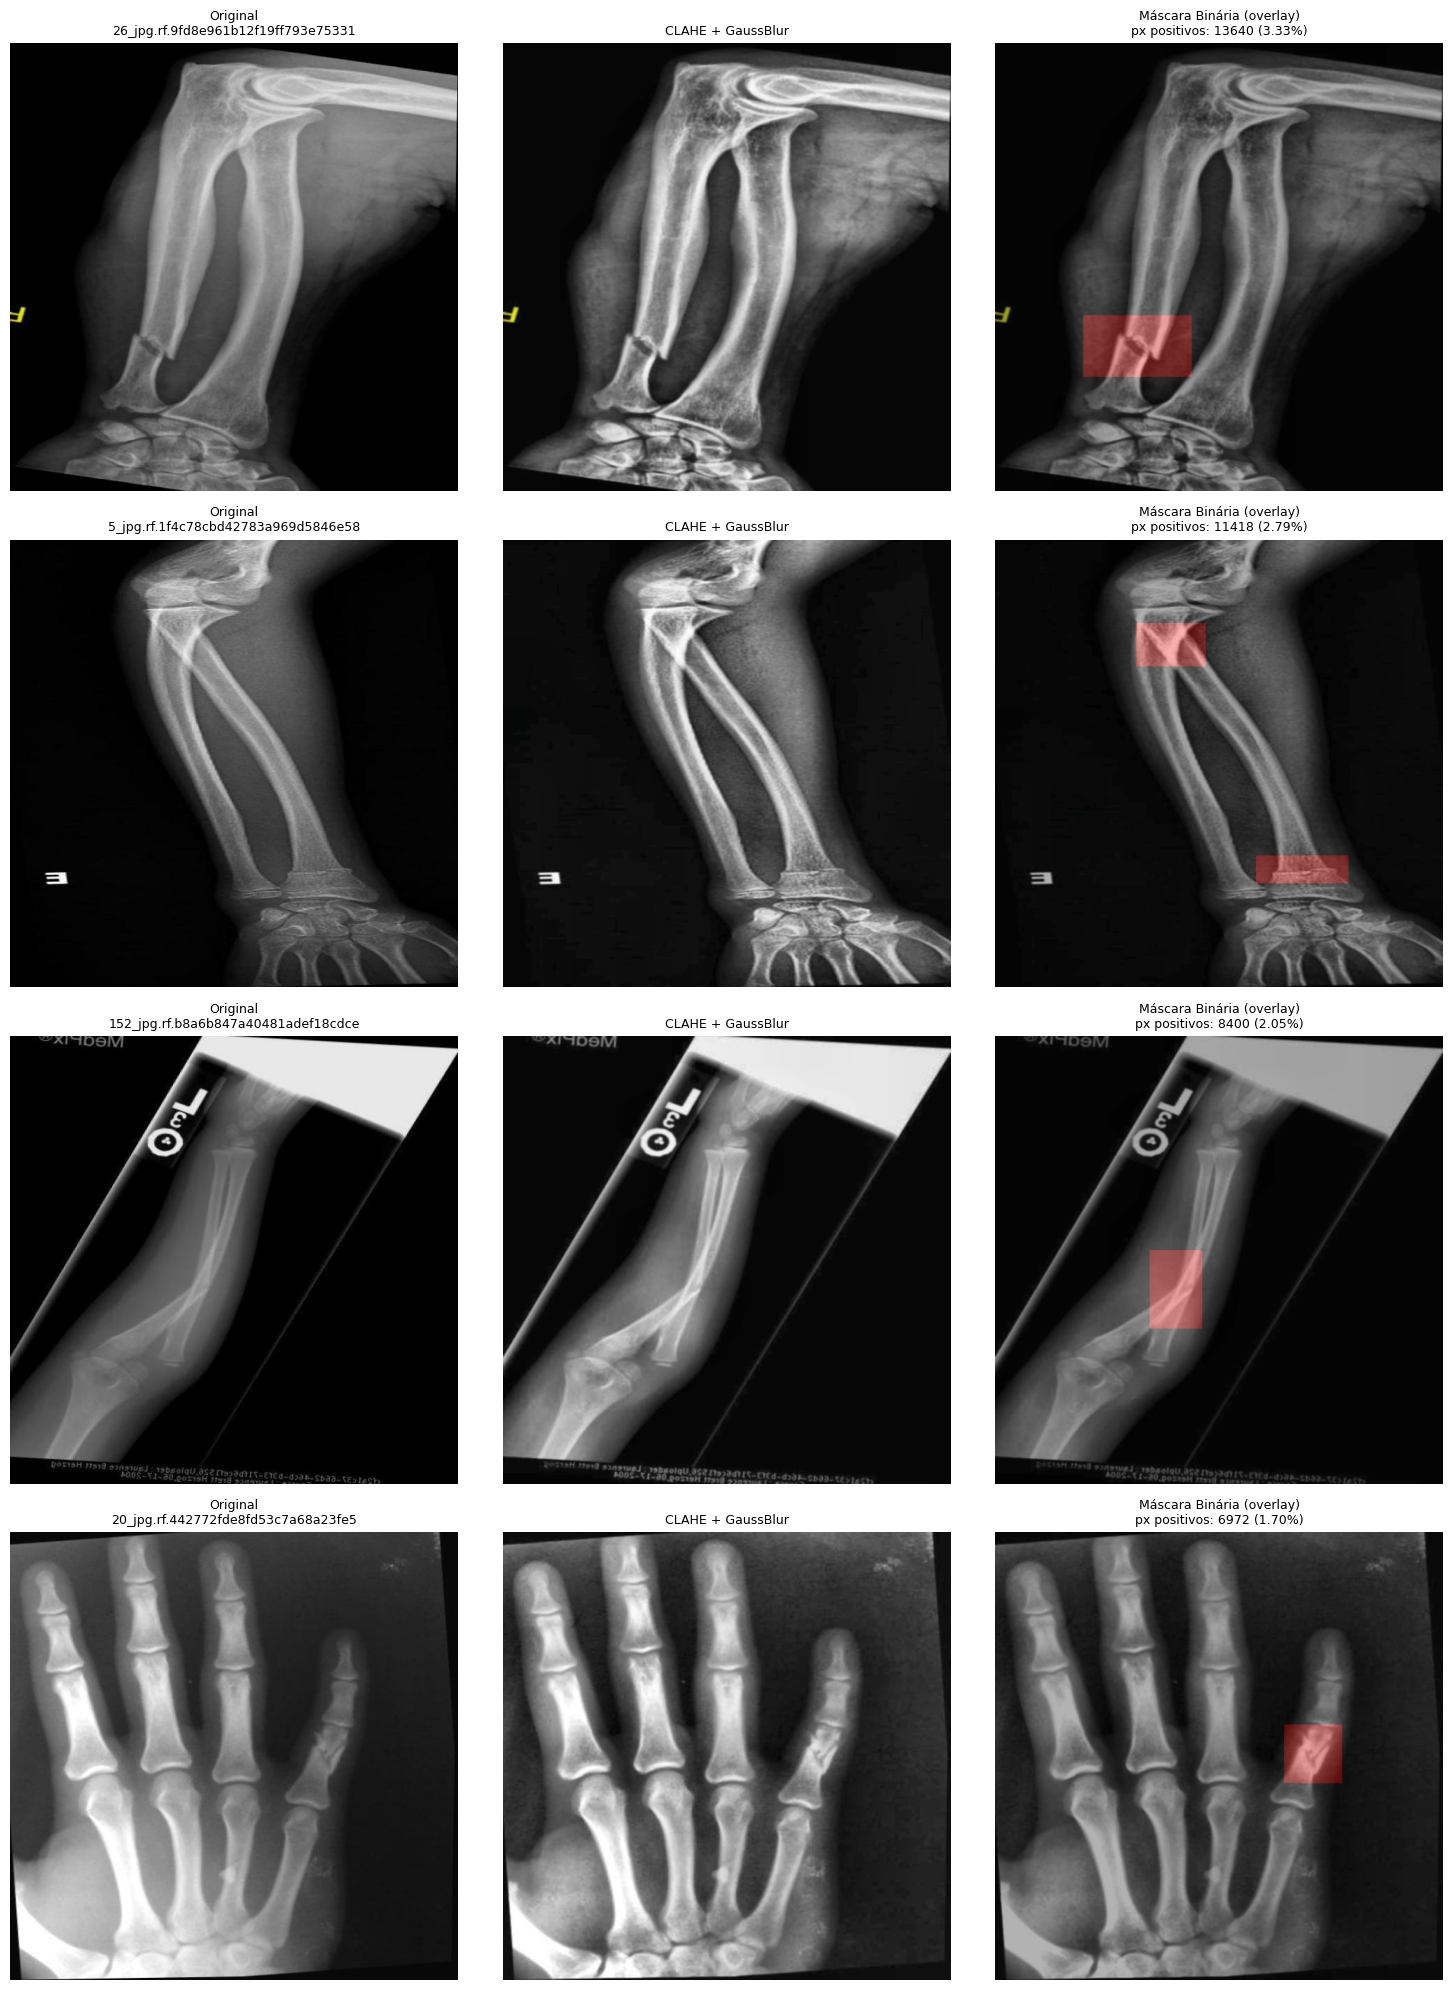

In [11]:
def visualize_samples(pairs, fracture_classes, n=4):
    """Visualiza n amostras: original, pré-processada, máscara overlay."""
    fig, axes = plt.subplots(n, 3, figsize=(15, 5*n))
    
    # Selecionar amostras com fratura
    fracture_pairs = [(ip, lp) for ip, lp in pairs if lp is not None]
    indices = np.random.choice(len(fracture_pairs), min(n, len(fracture_pairs)), replace=False)
    
    for i, idx in enumerate(indices):
        img_path, label_path = fracture_pairs[idx]
        
        # Carregar
        raw_img = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
        h, w = raw_img.shape[:2]
        
        preprocessed = preprocess_image(raw_img.copy())
        binary_mask = yolo_to_binary_mask(label_path, h, w, fracture_classes)
        
        name = os.path.basename(img_path)[:35]
        
        axes[i, 0].imshow(raw_img)
        axes[i, 0].set_title(f'Original\n{name}', fontsize=9)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(preprocessed)
        axes[i, 1].set_title('CLAHE + GaussBlur', fontsize=9)
        axes[i, 1].axis('off')
        
        overlay = preprocessed.copy().astype(np.float32) / 255.0
        mask_rgb = np.zeros_like(overlay)
        mask_rgb[:, :, 0] = binary_mask
        blended = np.clip(0.7 * overlay + 0.3 * mask_rgb, 0, 1)
        
        pos_px = int(binary_mask.sum())
        total_px = binary_mask.size
        axes[i, 2].imshow(blended)
        axes[i, 2].set_title(f'Máscara Binária (overlay)\npx positivos: {pos_px} ({pos_px/total_px*100:.2f}%)', fontsize=9)
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.RESULTS_DIR, 'sample_data.png'), dpi=150, bbox_inches='tight')
    plt.show()

visualize_samples(train_pairs, cfg.FRACTURE_CLASSES, n=4)

## 11. Modelo U-Net com Encoder ResNet34

Usamos `segmentation_models_pytorch` para criar uma U-Net com:
- **Encoder**: ResNet34 pré-treinado no ImageNet (transfer learning)
- **Decoder**: U-Net padrão com skip connections
- **Saída**: 1 canal (sigmoid → probabilidade de fratura)

In [12]:
def build_model(cfg):
    """Constrói modelo U-Net com encoder pré-treinado."""
    model = smp.Unet(
        encoder_name=cfg.ENCODER,
        encoder_weights=cfg.ENCODER_WEIGHTS,
        in_channels=cfg.IN_CHANNELS,
        classes=cfg.NUM_CLASSES,
        activation=None  # Sigmoid aplicado na loss
    )
    return model.to(cfg.DEVICE)

model = build_model(cfg)

# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Modelo: U-Net + {cfg.ENCODER}')
print(f'  Total de parâmetros: {total_params:,}')
print(f'  Parâmetros treináveis: {trainable_params:,}')

Modelo: U-Net + resnet34
  Total de parâmetros: 24,436,369
  Parâmetros treináveis: 24,436,369


## 12. Loss Function: BCE + Dice Loss

Combinação robusta para segmentação com classes desbalanceadas:
- **BCE com pos_weight**: Penaliza mais os falsos negativos
- **Dice Loss**: Otimiza diretamente a métrica Dice/F1

In [13]:
class BCEDiceLoss(nn.Module):
    """Combinação de BCE + Dice Loss."""
    def __init__(self, pos_weight=None, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        pw = pos_weight.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu')) if pos_weight is not None else None
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pw)
        self.dice = DiceLoss(mode='binary', from_logits=True)
    
    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        dice_loss = self.dice(pred, target)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

criterion = BCEDiceLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=cfg.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

print('Loss: BCE + Dice Loss')
print(f'Optimizer: AdamW (lr={cfg.LEARNING_RATE}, wd={cfg.WEIGHT_DECAY})')
print(f'Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)')

Loss: BCE + Dice Loss
Optimizer: AdamW (lr=0.0001, wd=0.0001)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


## 13. Métricas de Avaliação

- **mIoU (mean Intersection over Union)**: Métrica principal para segmentação
- **Dice Score (F1)**: Harmonic mean de precision e recall
- **Precision e Recall**: Para análise detalhada

In [14]:
def compute_metrics(pred_mask, true_mask, threshold=0.5):
    """Calcula IoU, Dice, Precision, Recall."""
    pred_bin = (torch.sigmoid(pred_mask) > threshold).float()
    
    intersection = (pred_bin * true_mask).sum()
    union = pred_bin.sum() + true_mask.sum() - intersection
    
    iou = (intersection + 1e-7) / (union + 1e-7)
    dice = (2 * intersection + 1e-7) / (pred_bin.sum() + true_mask.sum() + 1e-7)
    precision = (intersection + 1e-7) / (pred_bin.sum() + 1e-7)
    recall = (intersection + 1e-7) / (true_mask.sum() + 1e-7)
    
    return {
        'iou': iou.item(),
        'dice': dice.item(),
        'precision': precision.item(),
        'recall': recall.item()
    }

print("Funções de métricas definidas.")

Funções de métricas definidas.


## 14. Loop de Treinamento com Early Stopping

- Treinamento com validação a cada época
- Early stopping baseado na loss de validação
- Checkpoint do melhor modelo
- Histórico de métricas para visualização

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    metrics_sum = {'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0}
    n_batches = 0
    
    for images, masks in tqdm(loader, desc='  Train', leave=False):
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        batch_metrics = compute_metrics(preds.detach(), masks)
        for k in metrics_sum:
            metrics_sum[k] += batch_metrics[k]
        n_batches += 1
    
    avg_loss = total_loss / n_batches
    avg_metrics = {k: v / n_batches for k, v in metrics_sum.items()}
    return avg_loss, avg_metrics


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    metrics_sum = {'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0}
    n_batches = 0
    
    for images, masks in tqdm(loader, desc='  Valid', leave=False):
        images = images.to(device)
        masks = masks.to(device)
        
        preds = model(images)
        loss = criterion(preds, masks)
        
        total_loss += loss.item()
        batch_metrics = compute_metrics(preds, masks)
        for k in metrics_sum:
            metrics_sum[k] += batch_metrics[k]
        n_batches += 1
    
    avg_loss = total_loss / n_batches
    avg_metrics = {k: v / n_batches for k, v in metrics_sum.items()}
    return avg_loss, avg_metrics

print("Funções de treinamento e validação definidas.")

Funções de treinamento e validação definidas.


In [16]:
# === TREINAMENTO ===
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': [],
           'train_iou': [], 'val_iou': [], 'lr': []}

checkpoint_path = os.path.join(cfg.CHECKPOINT_DIR, 'best_model.pth')

print(f'Iniciando treinamento...')
print(f'  Device: {cfg.DEVICE}')
print(f'  Epochs: {cfg.EPOCHS}')
print(f'  Patience: {cfg.PATIENCE}')
print(f'  Checkpoint: {checkpoint_path}')
print()

for epoch in range(cfg.EPOCHS):
    print(f'Epoch {epoch+1}/{cfg.EPOCHS}')
    
    # Treinar
    train_loss, train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, cfg.DEVICE
    )
    
    # Validar
    val_loss, val_metrics = validate(
        model, valid_loader, criterion, cfg.DEVICE
    )
    
    # Scheduler
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    
    # Histórico
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dice'].append(train_metrics['dice'])
    history['val_dice'].append(val_metrics['dice'])
    history['train_iou'].append(train_metrics['iou'])
    history['val_iou'].append(val_metrics['iou'])
    history['lr'].append(current_lr)
    
    print(f'  Train Loss: {train_loss:.4f} | Dice: {train_metrics["dice"]:.4f} | IoU: {train_metrics["iou"]:.4f}')
    print(f'  Valid Loss: {val_loss:.4f} | Dice: {val_metrics["dice"]:.4f} | IoU: {val_metrics["iou"]:.4f}')
    print(f'  LR: {current_lr:.6f}')
    
    # Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_metrics': val_metrics,
        }, checkpoint_path)
        print(f'  ★ Melhor modelo salvo! (val_loss={val_loss:.4f})')
    else:
        patience_counter += 1
        print(f'  Sem melhoria ({patience_counter}/{cfg.PATIENCE})')
    
    # Early Stopping
    if patience_counter >= cfg.PATIENCE:
        print(f'\n⚠ Early stopping na época {epoch+1}')
        break
    
    print()

print(f'\nTreinamento concluído!')
print(f'Melhor val_loss: {best_val_loss:.4f}')

Iniciando treinamento...
  Device: cpu
  Epochs: 100
  Patience: 15
  Checkpoint: c:\Users\leona\OneDrive\Documentos\Unet_bones\checkpoints\best_model.pth

Epoch 1/100


  Train:   0%|          | 0/336 [00:00<?, ?it/s]

  Valid:   0%|          | 0/32 [00:00<?, ?it/s]

  Train Loss: 0.8847 | Dice: 0.1472 | IoU: 0.0806
  Valid Loss: 0.7302 | Dice: 0.3378 | IoU: 0.2137
  LR: 0.000100
  ★ Melhor modelo salvo! (val_loss=0.7302)

Epoch 2/100


  Train:   0%|          | 0/336 [00:00<?, ?it/s]

...

  Valid:   0%|          | 0/32 [00:00<?, ?it/s]

  Train Loss: 0.1802 | Dice: 0.7891 | IoU: 0.6560
  Valid Loss: 0.3877 | Dice: 0.7520 | IoU: 0.6084
  LR: 0.000025
  Sem melhoria (14/15)

Epoch 35/100


  Train:   0%|          | 0/336 [00:00<?, ?it/s]

  Valid:   0%|          | 0/32 [00:00<?, ?it/s]

  Train Loss: 0.1734 | Dice: 0.7924 | IoU: 0.6608
  Valid Loss: 0.3801 | Dice: 0.7636 | IoU: 0.6233
  LR: 0.000025
  Sem melhoria (15/15)

⚠ Early stopping na época 35

Treinamento concluído!
Melhor val_loss: 0.2936


## 15. Visualização do Treinamento

Curvas de loss e métricas ao longo do treinamento.

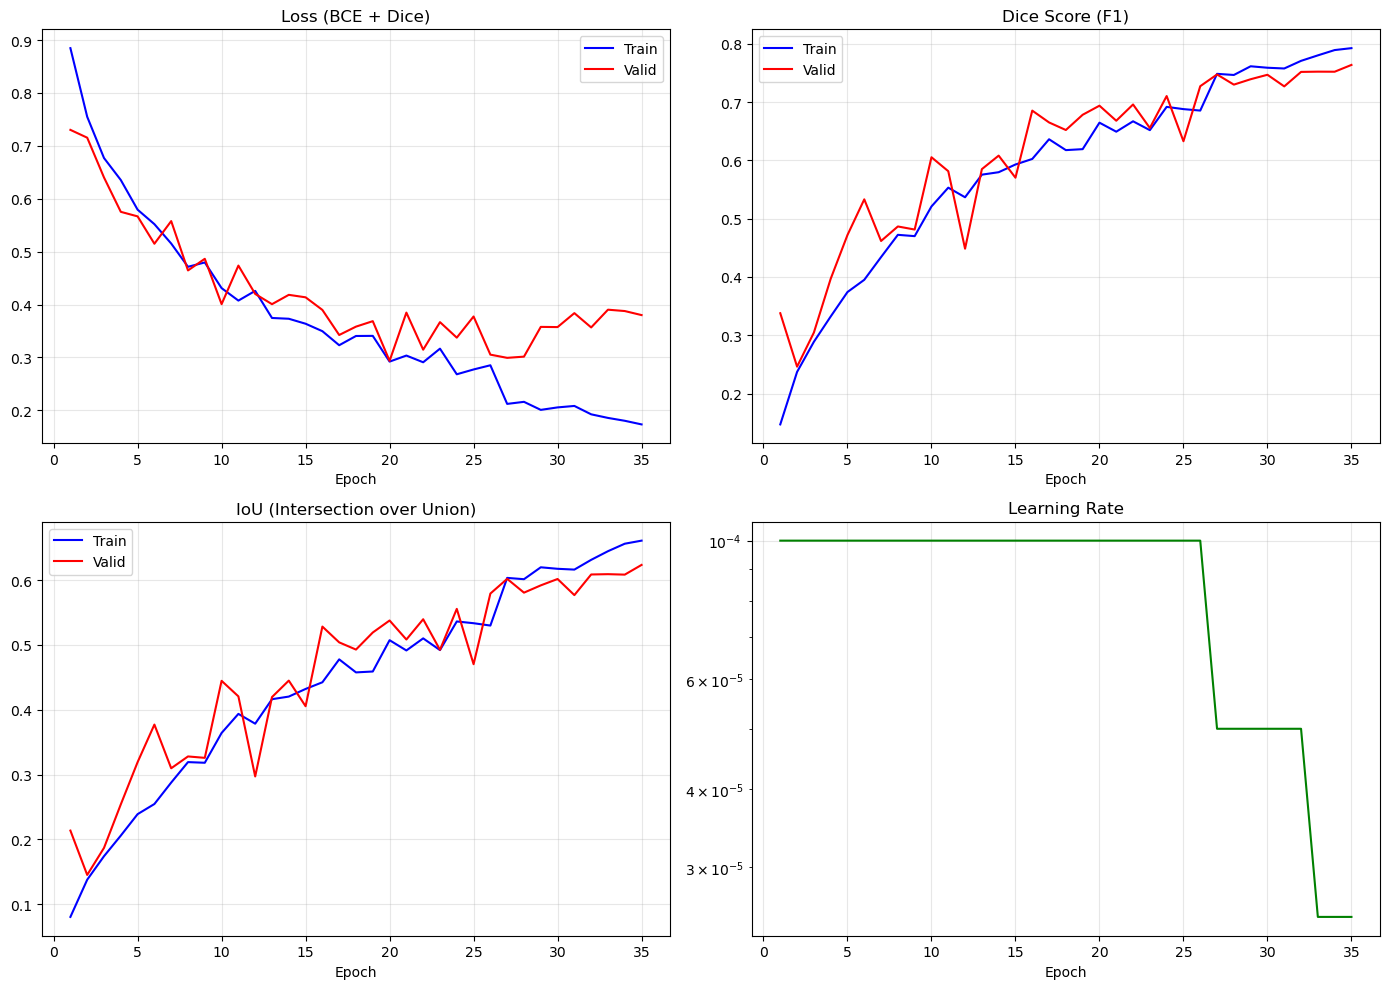

In [17]:
def plot_training_history(history):
    """Plota curvas de treinamento."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train')
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Valid')
    axes[0, 0].set_title('Loss (BCE + Dice)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Dice Score
    axes[0, 1].plot(epochs, history['train_dice'], 'b-', label='Train')
    axes[0, 1].plot(epochs, history['val_dice'], 'r-', label='Valid')
    axes[0, 1].set_title('Dice Score (F1)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # IoU
    axes[1, 0].plot(epochs, history['train_iou'], 'b-', label='Train')
    axes[1, 0].plot(epochs, history['val_iou'], 'r-', label='Valid')
    axes[1, 0].set_title('IoU (Intersection over Union)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Learning Rate
    axes[1, 1].plot(epochs, history['lr'], 'g-')
    axes[1, 1].set_title('Learning Rate')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.RESULTS_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history)

## 16. Avaliação no Conjunto de Teste

Avaliação final usando o melhor modelo salvo.

In [18]:
# Carregar melhor modelo
checkpoint = torch.load(checkpoint_path, map_location=cfg.DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Modelo carregado da época {checkpoint["epoch"]} (val_loss={checkpoint["val_loss"]:.4f})')

# Avaliar no teste
test_loss, test_metrics = validate(model, test_loader, criterion, cfg.DEVICE)

print(f'\n=== Resultados no Conjunto de Teste ===')
print(f'  Loss:      {test_loss:.4f}')
print(f'  IoU:       {test_metrics["iou"]:.4f}')
print(f'  Dice (F1): {test_metrics["dice"]:.4f}')
print(f'  Precision: {test_metrics["precision"]:.4f}')
print(f'  Recall:    {test_metrics["recall"]:.4f}')

Modelo carregado da época 20 (val_loss=0.2936)


  Valid:   0%|          | 0/64 [00:00<?, ?it/s]


=== Resultados no Conjunto de Teste ===
  Loss:      0.3142
  IoU:       0.5434
  Dice (F1): 0.6742
  Precision: 0.5962
  Recall:    0.9109


## 17. Visualização das Predições

Comparação visual: Imagem | Ground Truth | Predição | Overlay
- Verde: True Positive (corretamente detectado)
- Vermelho: False Positive (falso alarme)
- Azul: False Negative (fratura não detectada)

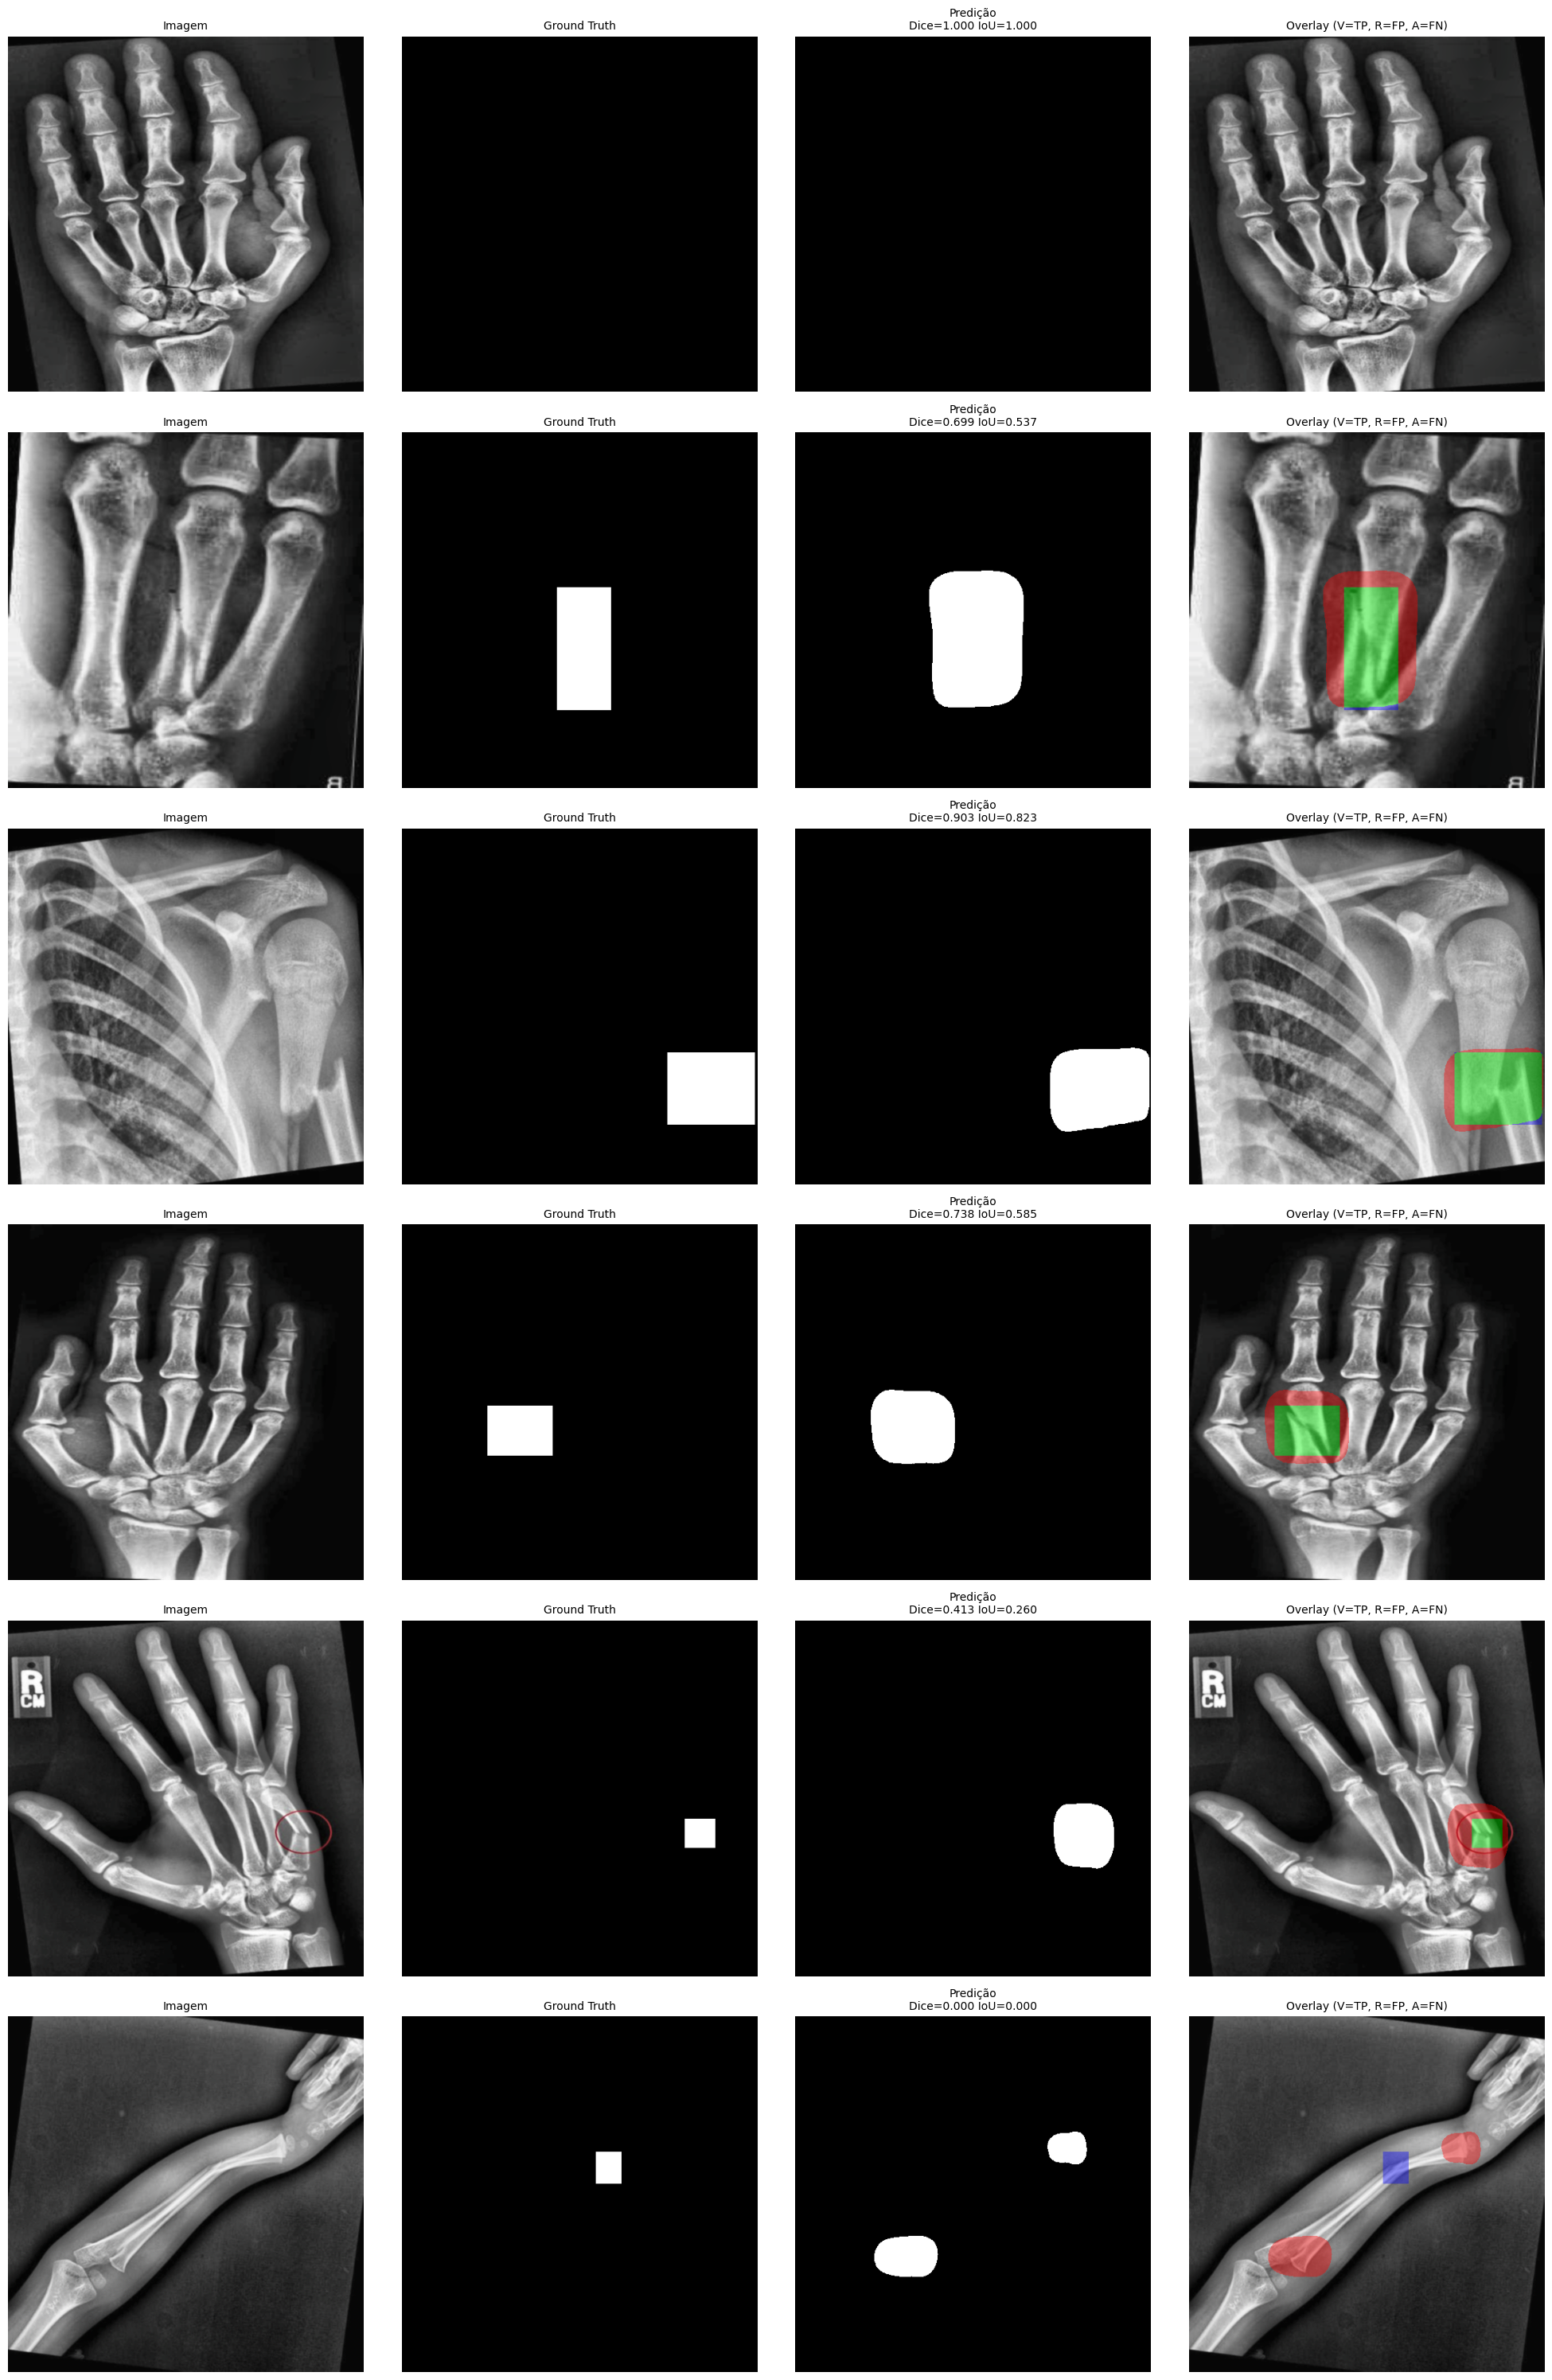

In [19]:
@torch.no_grad()
def visualize_predictions(model, dataset, cfg, n=6):
    """Visualiza predições vs ground truth."""
    model.eval()
    
    # Selecionar amostras
    indices = np.random.choice(len(dataset), min(n, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(n, 4, figsize=(20, 5*n))
    if n == 1:
        axes = axes[np.newaxis, :]
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        
        # Predição
        pred = model(image.unsqueeze(0).to(cfg.DEVICE))
        pred_mask = (torch.sigmoid(pred) > 0.5).float().cpu().squeeze()
        true_mask = mask.squeeze()
        
        # Denormalizar imagem
        img = image.permute(1, 2, 0).numpy()
        img = img * std + mean
        img = np.clip(img, 0, 1)
        
        # Métricas da amostra
        m = compute_metrics(pred.cpu(), mask.unsqueeze(0))
        
        # Imagem original
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Imagem', fontsize=10)
        axes[i, 0].axis('off')
        
        # Ground Truth
        axes[i, 1].imshow(true_mask, cmap='gray')
        axes[i, 1].set_title('Ground Truth', fontsize=10)
        axes[i, 1].axis('off')
        
        # Predição
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title(f'Predição\nDice={m["dice"]:.3f} IoU={m["iou"]:.3f}', fontsize=10)
        axes[i, 2].axis('off')
        
        # Overlay colorido
        overlay = img.copy()
        tp = (pred_mask.numpy() > 0) & (true_mask.numpy() > 0)  # Verde
        fp = (pred_mask.numpy() > 0) & (true_mask.numpy() == 0) # Vermelho
        fn = (pred_mask.numpy() == 0) & (true_mask.numpy() > 0) # Azul
        
        overlay[tp] = [0, 1, 0]
        overlay[fp] = [1, 0, 0]
        overlay[fn] = [0, 0, 1]
        
        blended = 0.6 * img + 0.4 * overlay
        blended = np.clip(blended, 0, 1)
        
        axes[i, 3].imshow(blended)
        axes[i, 3].set_title('Overlay (V=TP, R=FP, A=FN)', fontsize=10)
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.RESULTS_DIR, 'predictions.png'), dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(model, test_dataset, cfg, n=6)

## 18. Análise de Distribuição das Classes

Análise da distribuição dos tipos de fratura no dataset.

Analisando classes:   0%|          | 0/1347 [00:00<?, ?it/s]


Distribuição de Classes (Train):
  Total de anotações: 1548
  Imagens sem label: 0



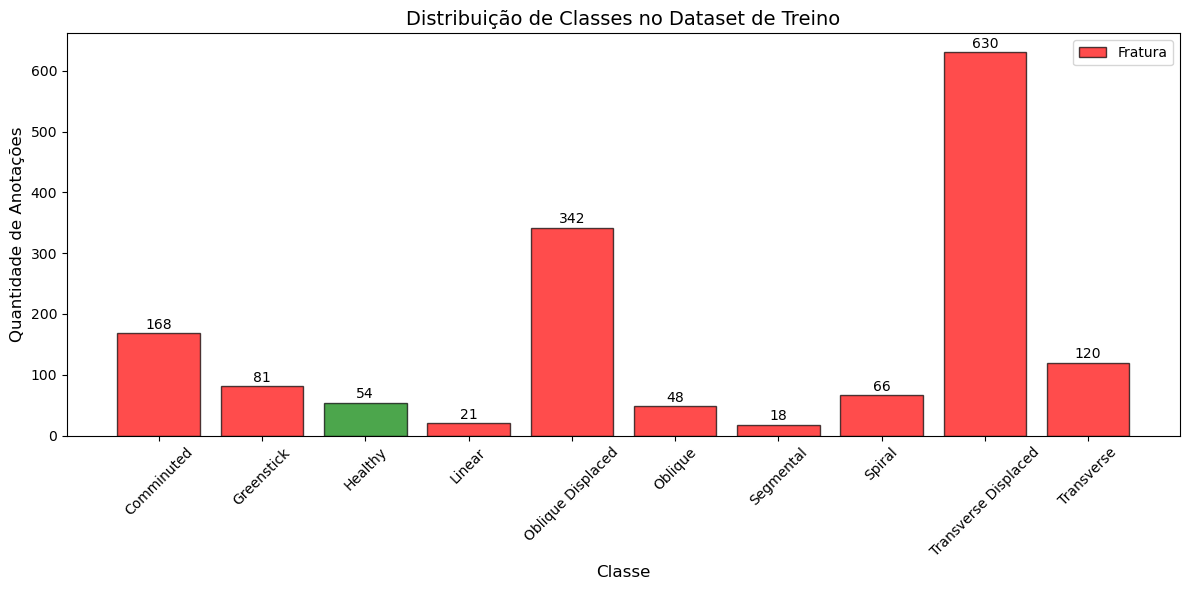

  [0] Comminuted               :   168 ( 10.9%) 🔴 Fratura
  [1] Greenstick               :    81 (  5.2%) 🔴 Fratura
  [2] Healthy                  :    54 (  3.5%) 🟢 Saudável
  [3] Linear                   :    21 (  1.4%) 🔴 Fratura
  [4] Oblique Displaced        :   342 ( 22.1%) 🔴 Fratura
  [5] Oblique                  :    48 (  3.1%) 🔴 Fratura
  [6] Segmental                :    18 (  1.2%) 🔴 Fratura
  [7] Spiral                   :    66 (  4.3%) 🔴 Fratura
  [8] Transverse Displaced     :   630 ( 40.7%) 🔴 Fratura
  [9] Transverse               :   120 (  7.8%) 🔴 Fratura


In [20]:
def analyze_class_distribution(pairs, class_names):
    """Analisa a distribuição de classes no dataset."""
    class_counts = {i: 0 for i in range(len(class_names))}
    total_annotations = 0
    images_with_no_labels = 0
    
    for img_path, label_path in tqdm(pairs, desc='Analisando classes'):
        if label_path is None or not os.path.exists(label_path):
            images_with_no_labels += 1
            continue
        
        annotations = parse_yolo_label(label_path)
        for class_id, _, _, _, _ in annotations:
            if class_id in class_counts:
                class_counts[class_id] += 1
                total_annotations += 1
    
    print(f'\nDistribuição de Classes (Train):')
    print(f'  Total de anotações: {total_annotations}')
    print(f'  Imagens sem label: {images_with_no_labels}')
    print()
    
    # Gráfico de barras
    fig, ax = plt.subplots(figsize=(12, 6))
    names = [class_names[i] for i in sorted(class_counts.keys())]
    counts = [class_counts[i] for i in sorted(class_counts.keys())]
    colors = ['red' if i != 2 else 'green' for i in sorted(class_counts.keys())]
    
    bars = ax.bar(names, counts, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title('Distribuição de Classes no Dataset de Treino', fontsize=14)
    ax.set_xlabel('Classe', fontsize=12)
    ax.set_ylabel('Quantidade de Anotações', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                str(count), ha='center', va='bottom', fontsize=10)
    
    ax.legend(['Fratura', 'Saudável'], loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.RESULTS_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    for i in sorted(class_counts.keys()):
        pct = class_counts[i] / total_annotations * 100 if total_annotations > 0 else 0
        tipo = '🟢 Saudável' if i == 2 else '🔴 Fratura'
        print(f'  [{i}] {class_names[i]:25s}: {class_counts[i]:5d} ({pct:5.1f}%) {tipo}')

analyze_class_distribution(train_pairs, cfg.CLASS_NAMES)

## 19. Resumo Final

Resumo dos resultados do treinamento e avaliação.

In [21]:
print('=' * 60)
print('RESUMO DO PIPELINE DE DETECÇÃO DE FRATURAS ÓSSEAS')
print('=' * 60)
print(f'\nDataset: Bone Fractures Detection (Roboflow)')
print(f'  Train: {len(train_pairs)} imagens')
print(f'  Valid: {len(valid_pairs)} imagens')
print(f'  Test:  {len(test_pairs)} imagens')
print(f'\nModelo: U-Net + {cfg.ENCODER} (ImageNet)')
print(f'  Parâmetros treináveis: {trainable_params:,}')
print(f'  Input: {cfg.IMG_SIZE}x{cfg.IMG_SIZE}x3')
print(f'  Output: {cfg.IMG_SIZE}x{cfg.IMG_SIZE}x1 (binário)')
print(f'\nTreinamento:')
print(f'  Épocas treinadas: {len(history["train_loss"])}')
print(f'  Melhor val_loss: {best_val_loss:.4f}')
if len(history['val_dice']) > 0:
    print(f'  Melhor val_dice: {max(history["val_dice"]):.4f}')
    print(f'  Melhor val_iou:  {max(history["val_iou"]):.4f}')
print(f'\nResultados no Teste:')
print(f'  Loss:      {test_loss:.4f}')
print(f'  IoU:       {test_metrics["iou"]:.4f}')
print(f'  Dice (F1): {test_metrics["dice"]:.4f}')
print(f'  Precision: {test_metrics["precision"]:.4f}')
print(f'  Recall:    {test_metrics["recall"]:.4f}')
print(f'\nArquivos salvos:')
print(f'  Checkpoint: {checkpoint_path}')
print(f'  Resultados: {cfg.RESULTS_DIR}/')
print('=' * 60)

RESUMO DO PIPELINE DE DETECÇÃO DE FRATURAS ÓSSEAS

Dataset: Bone Fractures Detection (Roboflow)
  Train: 1347 imagens
  Valid: 128 imagens
  Test:  64 imagens

Modelo: U-Net + resnet34 (ImageNet)
  Parâmetros treináveis: 24,436,369
  Input: 512x512x3
  Output: 512x512x1 (binário)

Treinamento:
  Épocas treinadas: 35
  Melhor val_loss: 0.2936
  Melhor val_dice: 0.7636
  Melhor val_iou:  0.6233

Resultados no Teste:
  Loss:      0.3142
  IoU:       0.5434
  Dice (F1): 0.6742
  Precision: 0.5962
  Recall:    0.9109

Arquivos salvos:
  Checkpoint: c:\Users\leona\OneDrive\Documentos\Unet_bones\checkpoints\best_model.pth
  Resultados: c:\Users\leona\OneDrive\Documentos\Unet_bones\results/
